In [1]:
import os
import glob
import numpy as np
import librosa
import soundfile as sf
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras import regularizers
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import KFold
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import confusion_matrix, classification_report

In [2]:
gpus = tf.config.list_physical_devices('GPU')
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)
print(f'GPU: {len(gpus)} device(s)')

GPU: 1 device(s)


In [3]:
SOURCE_DIR    = 'audio_files'
AUGMENTED_DIR = 'augmented_audio'
CACHE_DIR     = 'feature_cache'
SAMPLE_RATE   = 22050
SAMPLES       = SAMPLE_RATE * 3
N_MELS        = 128
N_FFT         = 2048
HOP_LENGTH    = 512
EMOTION_NAMES = ['neutral','calm','happy','sad','angry','fearful','disgust','surprised']

In [4]:
def fix_length(y):
    if len(y) > SAMPLES:
        return y[:SAMPLES]
    pad = SAMPLES - len(y)
    return np.pad(y, (pad // 2, pad - pad // 2), 'constant')

def to_3ch(y, sr):
    mel    = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=N_MELS, n_fft=N_FFT, hop_length=HOP_LENGTH, fmax=8000)
    mel_db = librosa.power_to_db(mel, ref=np.max)
    return np.stack([mel_db, librosa.feature.delta(mel_db), librosa.feature.delta(mel_db, order=2)], axis=-1)

def wav_to_feat(path):
    try:
        y, sr = librosa.load(path, sr=SAMPLE_RATE)
        return to_3ch(fix_length(y), sr)
    except:
        return None

In [5]:
CALM_NEUTRAL = {'02', '03'}
os.makedirs(AUGMENTED_DIR, exist_ok=True)

existing = glob.glob(os.path.join(AUGMENTED_DIR, '*.wav'))
if not existing:
    for fname in os.listdir(SOURCE_DIR):
        if not fname.endswith('.wav'):
            continue
        y, sr  = librosa.load(os.path.join(SOURCE_DIR, fname), sr=SAMPLE_RATE)
        parts  = fname.split('-')
        ecode  = parts[2] if len(parts) >= 3 else None
        base   = os.path.join(AUGMENTED_DIR, '{}' + fname)

        sf.write(base.format('orig_'),    y, sr)
        sf.write(base.format('noise_'),   y + 0.035*np.random.uniform()*np.amax(y)*np.random.normal(size=len(y)), sr)
        sf.write(base.format('strfast_'), fix_length(librosa.effects.time_stretch(y=y, rate=1.2)), sr)
        sf.write(base.format('pitch_'),   librosa.effects.pitch_shift(y=y, sr=sr, n_steps=0.7), sr)

        if ecode in CALM_NEUTRAL:
            sf.write(base.format('strslow_'), fix_length(librosa.effects.time_stretch(y=y, rate=0.85)), sr)
            sf.write(base.format('pup_'),     librosa.effects.pitch_shift(y=y, sr=sr, n_steps=1.5), sr)
            sf.write(base.format('pdn_'),     librosa.effects.pitch_shift(y=y, sr=sr, n_steps=-1.5), sr)
            n2 = y + 0.035*np.random.uniform()*np.amax(y)*np.random.normal(size=len(y))
            sf.write(base.format('noise2_'),  n2 + 0.035*np.random.uniform()*np.amax(n2)*np.random.normal(size=len(n2)), sr)
    print('Augmentation done')
else:
    print(f'Skipped — {len(existing)} augmented files already exist')

Skipped — 9888 augmented files already exist


In [6]:
os.makedirs(CACHE_DIR, exist_ok=True)

cache_X_path = os.path.join(CACHE_DIR, 'X.npy')
cache_y_path = os.path.join(CACHE_DIR, 'y.npy')
cache_src_path = os.path.join(CACHE_DIR, 'sources.npy')

if os.path.exists(cache_X_path):
    X_all     = np.load(cache_X_path)
    y_all     = np.load(cache_y_path)
    sources   = np.load(cache_src_path)  
    print(f'Loaded from cache: {X_all.shape}')
else:
    feats, labs, srcs = [], [], []
    all_wavs = sorted(glob.glob(os.path.join(AUGMENTED_DIR, '*.wav')))
    for i, path in enumerate(all_wavs):
        fname = os.path.basename(path)
        stem  = fname.split('_', 1)[-1] if '_' in fname else fname
        parts = stem.replace('.wav','').split('-')
        if len(parts) < 3:
            continue
        try:
            ecode = int(parts[2]) - 1
        except ValueError:
            continue
        feat = wav_to_feat(path)
        if feat is not None:
            feats.append(feat)
            labs.append(ecode)
            srcs.append(stem)            
        if i % 200 == 0:
            print(f'  {i}/{len(all_wavs)} processed...')

    X_all   = np.array(feats,  dtype=np.float32)
    y_all   = np.array(labs,   dtype=np.int32)
    sources = np.array(srcs)
    np.save(cache_X_path,   X_all)
    np.save(cache_y_path,   y_all)
    np.save(cache_src_path, sources)
    print(f'Cached: {X_all.shape}')

Loaded from cache: (9888, 128, 130, 3)


In [7]:
from tensorflow.keras.layers import GlobalAveragePooling2D, Input
from tensorflow.keras.models import Model


## Extract intensity + gender labels from filenames

In [8]:
def extract_labels(source_stem):
    """Parse RAVDESS filename stem -> (emotion, intensity, gender)
    Filename: 03-01-06-02-01-01-12.wav
    parts[2]=emotion(1-8), parts[3]=intensity(1=normal,2=strong), parts[6]=actor(1-24)
    Gender: odd actor = male(0), even actor = female(1)
    """
    parts = source_stem.replace('.wav','').split('-')
    if len(parts) < 7:
        return None, None, None
    try:
        emotion   = int(parts[2]) - 1          # 0-7
        intensity = int(parts[3]) - 1          # 0=normal, 1=strong
        actor     = int(parts[6])
        gender    = 0 if actor % 2 == 1 else 1 # 0=male, 1=female
        return emotion, intensity, gender
    except (ValueError, IndexError):
        return None, None, None

intensity_all = []
gender_all    = []
valid_mask    = []

for stem in sources:
    e, inten, gen = extract_labels(stem)
    if e is None:
        valid_mask.append(False)
        intensity_all.append(0)
        gender_all.append(0)
    else:
        valid_mask.append(True)
        intensity_all.append(inten)
        gender_all.append(gen)

valid_mask    = np.array(valid_mask)
intensity_all = np.array(intensity_all, dtype=np.int32)
gender_all    = np.array(gender_all,    dtype=np.int32)

# Filter to valid only
X_all       = X_all[valid_mask]
y_all       = y_all[valid_mask]
sources     = sources[valid_mask]
intensity_all = intensity_all[valid_mask]
gender_all    = gender_all[valid_mask]

INTENSITY_NAMES = ['normal', 'strong']
GENDER_NAMES    = ['male', 'female']

print(f'Samples: {len(y_all)}')
print(f'Intensity — normal: {(intensity_all==0).sum()}  strong: {(intensity_all==1).sum()}')
print(f'Gender    — male:   {(gender_all==0).sum()}    female: {(gender_all==1).sum()}')
print(f'Neutral intensity check: {intensity_all[y_all==0].sum()} strong (should be 0)')


Samples: 9888
Intensity — normal: 5184  strong: 4704
Gender    — male:   4944    female: 4944
Neutral intensity check: 0 strong (should be 0)


## Multi-task model — shared backbone + 3 heads

In [9]:
def focal_loss(gamma=2.0):
    def loss_fn(y_true, y_pred):
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0)
        ce     = -y_true * tf.math.log(y_pred)
        weight = y_true * tf.math.pow(1.0 - y_pred, gamma)
        return tf.reduce_mean(tf.reduce_sum(weight * ce, axis=1))
    return loss_fn


def build_multitask_model(input_shape):

    inputs = Input(shape=input_shape)

    x = Conv2D(32, (3,3), activation='relu', padding='same',
               kernel_regularizer=regularizers.l2(0.001))(inputs)
    x = BatchNormalization()(x)
    x = MaxPooling2D((2,2))(x)
    x = Dropout(0.25)(x)

    x = Conv2D(64, (3,3), activation='relu', padding='same',
               kernel_regularizer=regularizers.l2(0.001))(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D((2,2))(x)
    x = Dropout(0.25)(x)

    x = Conv2D(128, (3,3), activation='relu', padding='same',
               kernel_regularizer=regularizers.l2(0.001))(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D((2,2))(x)
    x = Dropout(0.3)(x)

    shared = GlobalAveragePooling2D()(x)               
    shared = Dense(128, activation='relu',
                   kernel_regularizer=regularizers.l2(0.001))(shared)
    shared = Dropout(0.4)(shared)


    h_emotion = Dense(64, activation='relu')(shared)
    h_emotion = Dropout(0.3)(h_emotion)
    out_emotion = Dense(8, activation='softmax', name='emotion')(h_emotion)

    h_intensity = Dense(32, activation='relu')(shared)
    h_intensity = Dropout(0.2)(h_intensity)
    out_intensity = Dense(2, activation='softmax', name='intensity')(h_intensity)

    h_gender = Dense(32, activation='relu')(shared)
    h_gender = Dropout(0.2)(h_gender)
    out_gender = Dense(2, activation='softmax', name='gender')(h_gender)

    model = Model(inputs=inputs,
                  outputs=[out_emotion, out_intensity, out_gender])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss={
            'emotion':   focal_loss(gamma=2.0),
            'intensity': 'categorical_crossentropy',
            'gender':    'categorical_crossentropy'
        },
        loss_weights={'emotion': 1.0, 'intensity': 0.3, 'gender': 0.2},
        metrics={
            'emotion':   'accuracy',
            'intensity': 'accuracy',
            'gender':    'accuracy'
        }
    )
    return model

test_model = build_multitask_model((128, 130, 3))
test_model.summary()
del test_model
tf.keras.backend.clear_session()


Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 128, 130, 3  0           []                               
                                )]                                                                
                                                                                                  
 conv2d (Conv2D)                (None, 128, 130, 32  896         ['input_1[0][0]']                
                                )                                                                 
                                                                                                  
 batch_normalization (BatchNorm  (None, 128, 130, 32  128        ['conv2d[0][0]']                 
 alization)                     )                                                             

## Training — 3-fold cross validation

In [10]:
BATCH_SIZE = 32

def make_dataset_mt(X, y_emo, y_int, y_gen, shuffle=False):
    """Multi-task dataset: one input, three label outputs."""
    ds = tf.data.Dataset.from_tensor_slices((
        X,
        {'emotion': y_emo, 'intensity': y_int, 'gender': y_gen}
    ))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(X), reshuffle_each_iteration=True)
    return ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)


unique_sources = np.unique(sources)
kfold          = KFold(n_splits=3, shuffle=True, random_state=42)
fold_results   = []

for fold, (tr_src_idx, va_src_idx) in enumerate(kfold.split(unique_sources)):
    print(f'\n── Fold {fold+1}/3 ──')

    tr_sources    = set(unique_sources[tr_src_idx])
    va_sources    = set(unique_sources[va_src_idx])
    tr_mask       = np.array([s in tr_sources for s in sources])
    va_mask       = np.array([s in va_sources for s in sources])
    tr_mask_final = tr_mask & ~va_mask

    X_tr  = X_all[tr_mask_final].astype(np.float32)
    X_va  = X_all[va_mask].astype(np.float32)

    y_emo_tr  = y_all[tr_mask_final]
    y_emo_va  = y_all[va_mask]
    y_int_tr  = intensity_all[tr_mask_final]
    y_int_va  = intensity_all[va_mask]
    y_gen_tr  = gender_all[tr_mask_final]
    y_gen_va  = gender_all[va_mask]

    y_emo_tr_cat = to_categorical(y_emo_tr, num_classes=8)
    y_emo_va_cat = to_categorical(y_emo_va, num_classes=8)
    y_int_tr_cat = to_categorical(y_int_tr, num_classes=2)
    y_int_va_cat = to_categorical(y_int_va, num_classes=2)
    y_gen_tr_cat = to_categorical(y_gen_tr, num_classes=2)
    y_gen_va_cat = to_categorical(y_gen_va, num_classes=2)

    cw = compute_class_weight('balanced', classes=np.arange(8), y=y_emo_tr)

    sample_weights = np.array([cw[e] for e in y_emo_tr])

    train_ds = make_dataset_mt(X_tr,
                               y_emo_tr_cat, y_int_tr_cat, y_gen_tr_cat,
                               shuffle=True)
    val_ds   = make_dataset_mt(X_va,
                               y_emo_va_cat, y_int_va_cat, y_gen_va_cat)



    tf.keras.backend.clear_session()
    model = build_multitask_model(X_tr.shape[1:])

    callbacks = [
        ReduceLROnPlateau(monitor='val_emotion_accuracy', patience=5,
                          factor=0.5, min_lr=1e-5, verbose=0),
        EarlyStopping(monitor='val_emotion_accuracy', patience=15,
                      restore_best_weights=True)
    ]

    model.fit(
        train_ds,
        epochs=100,
        validation_data=val_ds,
        callbacks=callbacks,
        verbose=1
    )

    preds = model.predict(val_ds, verbose=0)
    pred_emo = np.argmax(preds[0], axis=1)
    pred_int = np.argmax(preds[1], axis=1)
    pred_gen = np.argmax(preds[2], axis=1)

    acc_emo = np.mean(pred_emo == y_emo_va)
    acc_int = np.mean(pred_int == y_int_va)
    acc_gen = np.mean(pred_gen == y_gen_va)

    fold_results.append({
        'fold':    fold+1,
        'model':   model,
        'acc_emo': acc_emo,
        'acc_int': acc_int,
        'acc_gen': acc_gen,
        'pred_emo': pred_emo, 'true_emo': y_emo_va,
        'pred_int': pred_int, 'true_int': y_int_va,
        'pred_gen': pred_gen, 'true_gen': y_gen_va,
    })
    print(f'Fold {fold+1}  emotion={acc_emo:.4f}  intensity={acc_int:.4f}  gender={acc_gen:.4f}')

best = max(fold_results, key=lambda x: x['acc_emo'])
model = best['model']
accs  = [r['acc_emo'] for r in fold_results]
print(f'\nEmotion  — Mean: {np.mean(accs):.4f}  Std: {np.std(accs):.4f}  Best fold: {best["fold"]}')
print(f'Intensity — Mean: {np.mean([r["acc_int"] for r in fold_results]):.4f}')
print(f'Gender    — Mean: {np.mean([r["acc_gen"] for r in fold_results]):.4f}')



── Fold 1/3 ──
Epoch 1/100
205/205 [==============================] - 23s 55ms/step - loss: 1.8384 - emotion_loss: 1.2778 - intensity_loss: 0.6796 - gender_loss: 0.6427 - emotion_accuracy: 0.3502 - intensity_accuracy: 0.5839 - gender_accuracy: 0.6093 - val_loss: 4.0432 - val_emotion_loss: 3.3319 - val_intensity_loss: 0.6938 - val_gender_loss: 1.4911 - val_emotion_accuracy: 0.2587 - val_intensity_accuracy: 0.5054 - val_gender_accuracy: 0.4892 - lr: 0.0010
Epoch 2/100
205/205 [==============================] - 11s 55ms/step - loss: 1.4701 - emotion_loss: 1.0150 - intensity_loss: 0.6229 - gender_loss: 0.3942 - emotion_accuracy: 0.4381 - intensity_accuracy: 0.6586 - gender_accuracy: 0.8290 - val_loss: 2.3123 - val_emotion_loss: 1.7093 - val_intensity_loss: 0.6310 - val_gender_loss: 1.1861 - val_emotion_accuracy: 0.2727 - val_intensity_accuracy: 0.6172 - val_gender_accuracy: 0.5000 - lr: 0.0010
Epoch 3/100
205/205 [==============================] - 10s 49ms/step - loss: 1.2977 - emotion_lo

## Evaluation — confusion matrices for all three tasks

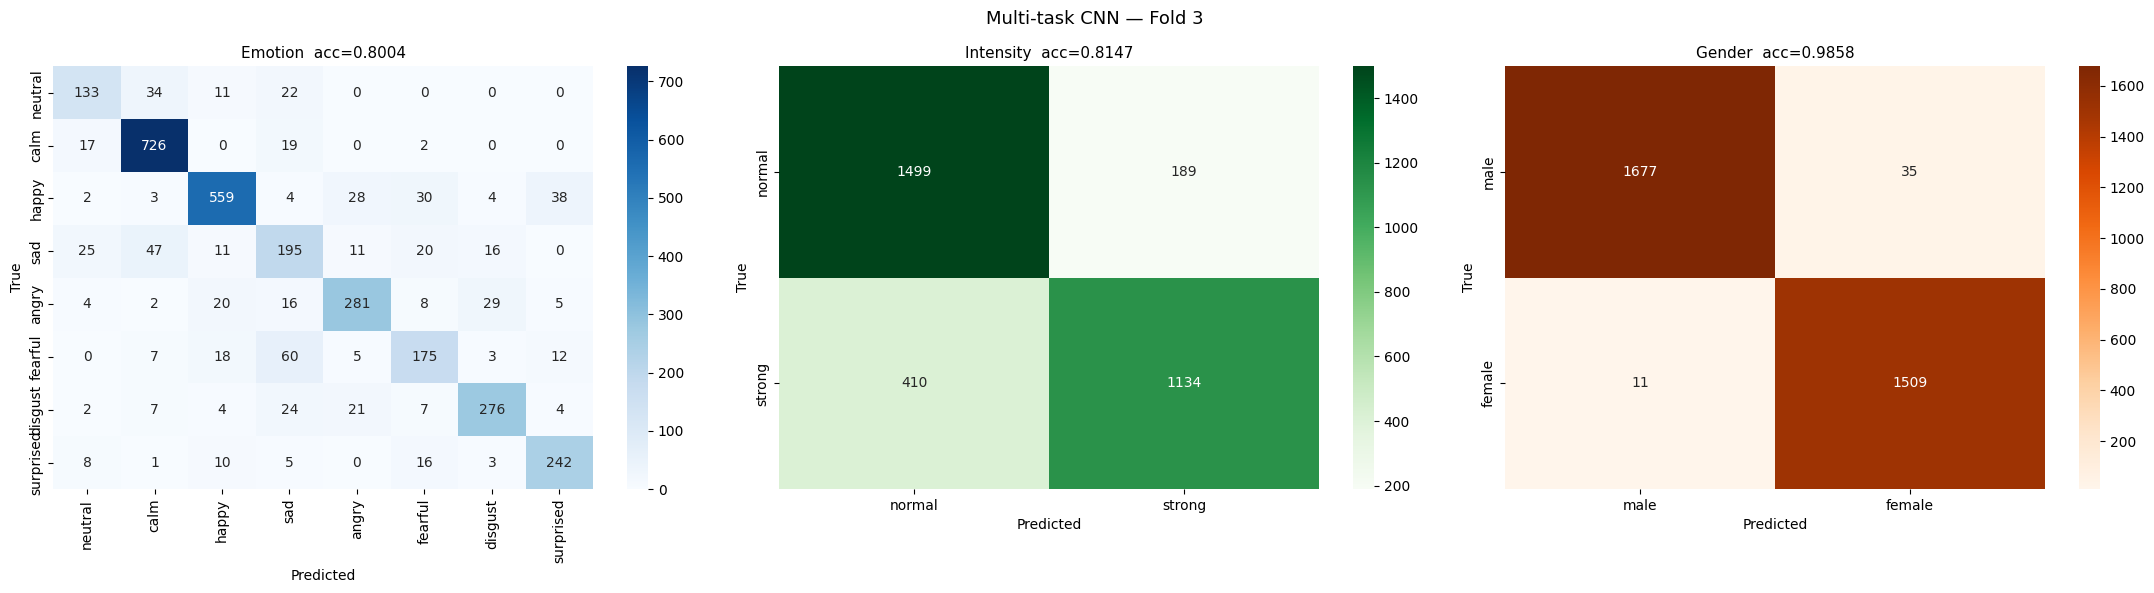


── Emotion ──
              precision    recall  f1-score   support

     neutral       0.70      0.67      0.68       200
        calm       0.88      0.95      0.91       764
       happy       0.88      0.84      0.86       668
         sad       0.57      0.60      0.58       325
       angry       0.81      0.77      0.79       365
     fearful       0.68      0.62      0.65       280
     disgust       0.83      0.80      0.82       345
   surprised       0.80      0.85      0.83       285

    accuracy                           0.80      3232
   macro avg       0.77      0.76      0.76      3232
weighted avg       0.80      0.80      0.80      3232

── Intensity ──
              precision    recall  f1-score   support

      normal       0.79      0.89      0.83      1688
      strong       0.86      0.73      0.79      1544

    accuracy                           0.81      3232
   macro avg       0.82      0.81      0.81      3232
weighted avg       0.82      0.81      0.81   

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

cm_emo = confusion_matrix(best['true_emo'], best['pred_emo'])
sns.heatmap(cm_emo, annot=True, fmt='d', cmap='Blues',
            xticklabels=EMOTION_NAMES, yticklabels=EMOTION_NAMES, ax=axes[0])
axes[0].set_title(f'Emotion  acc={best["acc_emo"]:.4f}', fontsize=11)
axes[0].set_ylabel('True'); axes[0].set_xlabel('Predicted')

cm_int = confusion_matrix(best['true_int'], best['pred_int'])
sns.heatmap(cm_int, annot=True, fmt='d', cmap='Greens',
            xticklabels=INTENSITY_NAMES, yticklabels=INTENSITY_NAMES, ax=axes[1])
axes[1].set_title(f'Intensity  acc={best["acc_int"]:.4f}', fontsize=11)
axes[1].set_ylabel('True'); axes[1].set_xlabel('Predicted')

cm_gen = confusion_matrix(best['true_gen'], best['pred_gen'])
sns.heatmap(cm_gen, annot=True, fmt='d', cmap='Oranges',
            xticklabels=GENDER_NAMES, yticklabels=GENDER_NAMES, ax=axes[2])
axes[2].set_title(f'Gender  acc={best["acc_gen"]:.4f}', fontsize=11)
axes[2].set_ylabel('True'); axes[2].set_xlabel('Predicted')

plt.suptitle(f'Multi-task CNN — Fold {best["fold"]}', fontsize=13)
plt.tight_layout()
plt.show()

print('\n── Emotion ──')
print(classification_report(best['true_emo'], best['pred_emo'], target_names=EMOTION_NAMES))
print('── Intensity ──')
print(classification_report(best['true_int'], best['pred_int'], target_names=INTENSITY_NAMES))
print('── Gender ──')
print(classification_report(best['true_gen'], best['pred_gen'], target_names=GENDER_NAMES))


In [12]:
model.save('best_multitask_model.h5')
print('Saved: best_multitask_model.h5')


Saved: best_multitask_model.h5


## Predict on your own voice files

In [15]:
test_files = sorted(glob.glob('test_file/*.wav'))
print(f'Found {len(test_files)} test files\n')
print(f'{"File":<25} {"Emotion":<12} {"Intensity":<10} {"Gender":<8} {"Conf"}')
print('─' * 65)

for test_file in test_files:
    y, sr  = librosa.load(test_file, sr=SAMPLE_RATE)
    feat   = to_3ch(fix_length(y), sr)[np.newaxis, ...]
    preds  = model.predict(feat, verbose=0)

    emo_idx  = np.argmax(preds[0][0])
    int_idx  = np.argmax(preds[1][0])
    gen_idx  = np.argmax(preds[2][0])

    emo_conf = preds[0][0][emo_idx]
    fname    = os.path.basename(test_file)

    print(f'{fname:<25} {EMOTION_NAMES[emo_idx]:<12} '
          f'{INTENSITY_NAMES[int_idx]:<10} '
          f'{GENDER_NAMES[gen_idx]:<8} '
          f'{emo_conf:.3f}')

Found 16 test files

File                      Emotion      Intensity  Gender   Conf
─────────────────────────────────────────────────────────────────
Angry1.wav                calm         strong     male     0.573
Angry2.wav                sad          normal     male     0.709
Calm1.wav                 calm         normal     male     0.804
Calm2.wav                 calm         strong     male     0.969
Disgust1.wav              calm         strong     male     0.802
Disgust2.wav              surprised    normal     male     0.784
Fear1.wav                 sad          strong     male     0.634
Fear2.wav                 sad          strong     female   0.778
Happy1.wav                sad          normal     male     0.612
Happy2.wav                surprised    normal     male     0.968
Neutral1.wav              sad          normal     male     0.739
Neutral2.wav              calm         normal     male     0.833
Sad1.wav                  sad          normal     male     0.972
Sad2